In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

# Verileri içinde bulunduran tablomu çektim
df = pd.read_csv("sample_data/data.csv")

df.drop(columns=["id"], inplace=True, errors = "ignore")# Tablo üzerinde id sütununu sildim gereksiz bir sütün olduğu için
df.dropna(axis=1, how="all", inplace=True)# içerisinde eksik veri bulunan sütunları sildik burda

print("Veri Seti Boyutu:", df.shape)
print("Sınıf Dağılımı:\n", df["diagnosis"].value_counts())

le = LabelEncoder() # LabelEncoder nesnesi oluşturdum , labelEncoder nesnesi kategorik sütünlları sayısal veriye dönüştürür
#Burada hedef sütun olan diagnosis (tanı) sütunudur bu sütun içerisinde M (Malignant-Kötü huylu tümör) ve B (Benign-iyi huylu tümör) bulunur.
#Ve bulunan B ve M için alfabetik sırada sayısal atama yapılır B - 0 M - 1 olur ve sütun değiştirilir
df["diagnosis"] = le.fit_transform(df["diagnosis"])

#Burada girdi değişkenleri içe çıktı değişkenini ayırıyorum
X = df.drop(columns=["diagnosis"])#diagnosis yani tanı harici tüm tabloyu aldık burası girdi katmanı için kullanılanak özellikler kısmını belirtir
y = df["diagnosis"] # sadece diagnosis sütununu atarız burası da çıktı sonuç katmanını beltirtir.

# Test ve eğitim verisini bölme burada yapılıyor. Burada %80 eğitim %20 test olacak şekilde ve
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42, #random_state=42 kısmında veriyi bölmek için kullanılacak rastgeleliği sabitliyoruz.Bu şekilde verimiz birebir aynı şekilde bölünür.
    stratify=y) #stratify=y ile de tablodaki dağılımı koruyarak eğitim ve test verimizi dağıtıyoruz

#Model seçimi ve inject edilmesi , burada random forest modelini seçtim. Farklı sayıda karar ağacından oluşan bu yapıda farklı farklı tahmiinlerde bulunur karar ağacları
#bu tahminlerin hangisi daha çok oy alırsa sonuç o olur, Burada n_estimators karar ağac sayısıdır burada genelde karar ağacı artarsa sonuçta iyileşme oluyormuş
#bende o yüzden 100-1000-10000 olacak şekilde 3 defa denedim ancak sonuçta bir iyileşme görmedim.
model = RandomForestClassifier(n_estimators=100, random_state=42)
#modelin eğitilmesi
model.fit(X_train, y_train)

#Modelin tahminde bulunması burada X_test verisi üzerinden tahminde bulunucak hasta mı değil mi diye
y_pred = model.predict(X_test)

#test verisinin gerçek sonucu olan y_pred ile y_test verilerinin karşılaştırılması ile bulunan accuracy_score,precision_score,recall_score ve f1_score bulunması
print("\n========= METRİKLER =========")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")# burada Accuracy gerçek değerler ile tahmmin değerlerini karşılaştırır. Toplam tahminlerimizin % kaçı doğru buluruz
print(f"Precision : {precision_score(y_test, y_pred):.4f}") #Precision  modelin hasta (M-1 çünkü) dediklerinin % kaçı gerçekten hasta
print(f"Recall    : {recall_score(y_test, y_pred):.4f}") #Recall modelin hasta olanların % kaçına hasta dediğimizi buluruz
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}") # f1 skoru precision ve recall’ın harmonik ortalamasıdır


Veri Seti Boyutu: (569, 31)
Sınıf Dağılımı:
 diagnosis
B    357
M    212
Name: count, dtype: int64

========= METRİKLER =========
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1-Score  : 0.9630

               precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Veri Seti Boyutu: (569, 31)
Sınıf Dağılımı:
 diagnosis
B    357
M    212
Name: count, dtype: int64


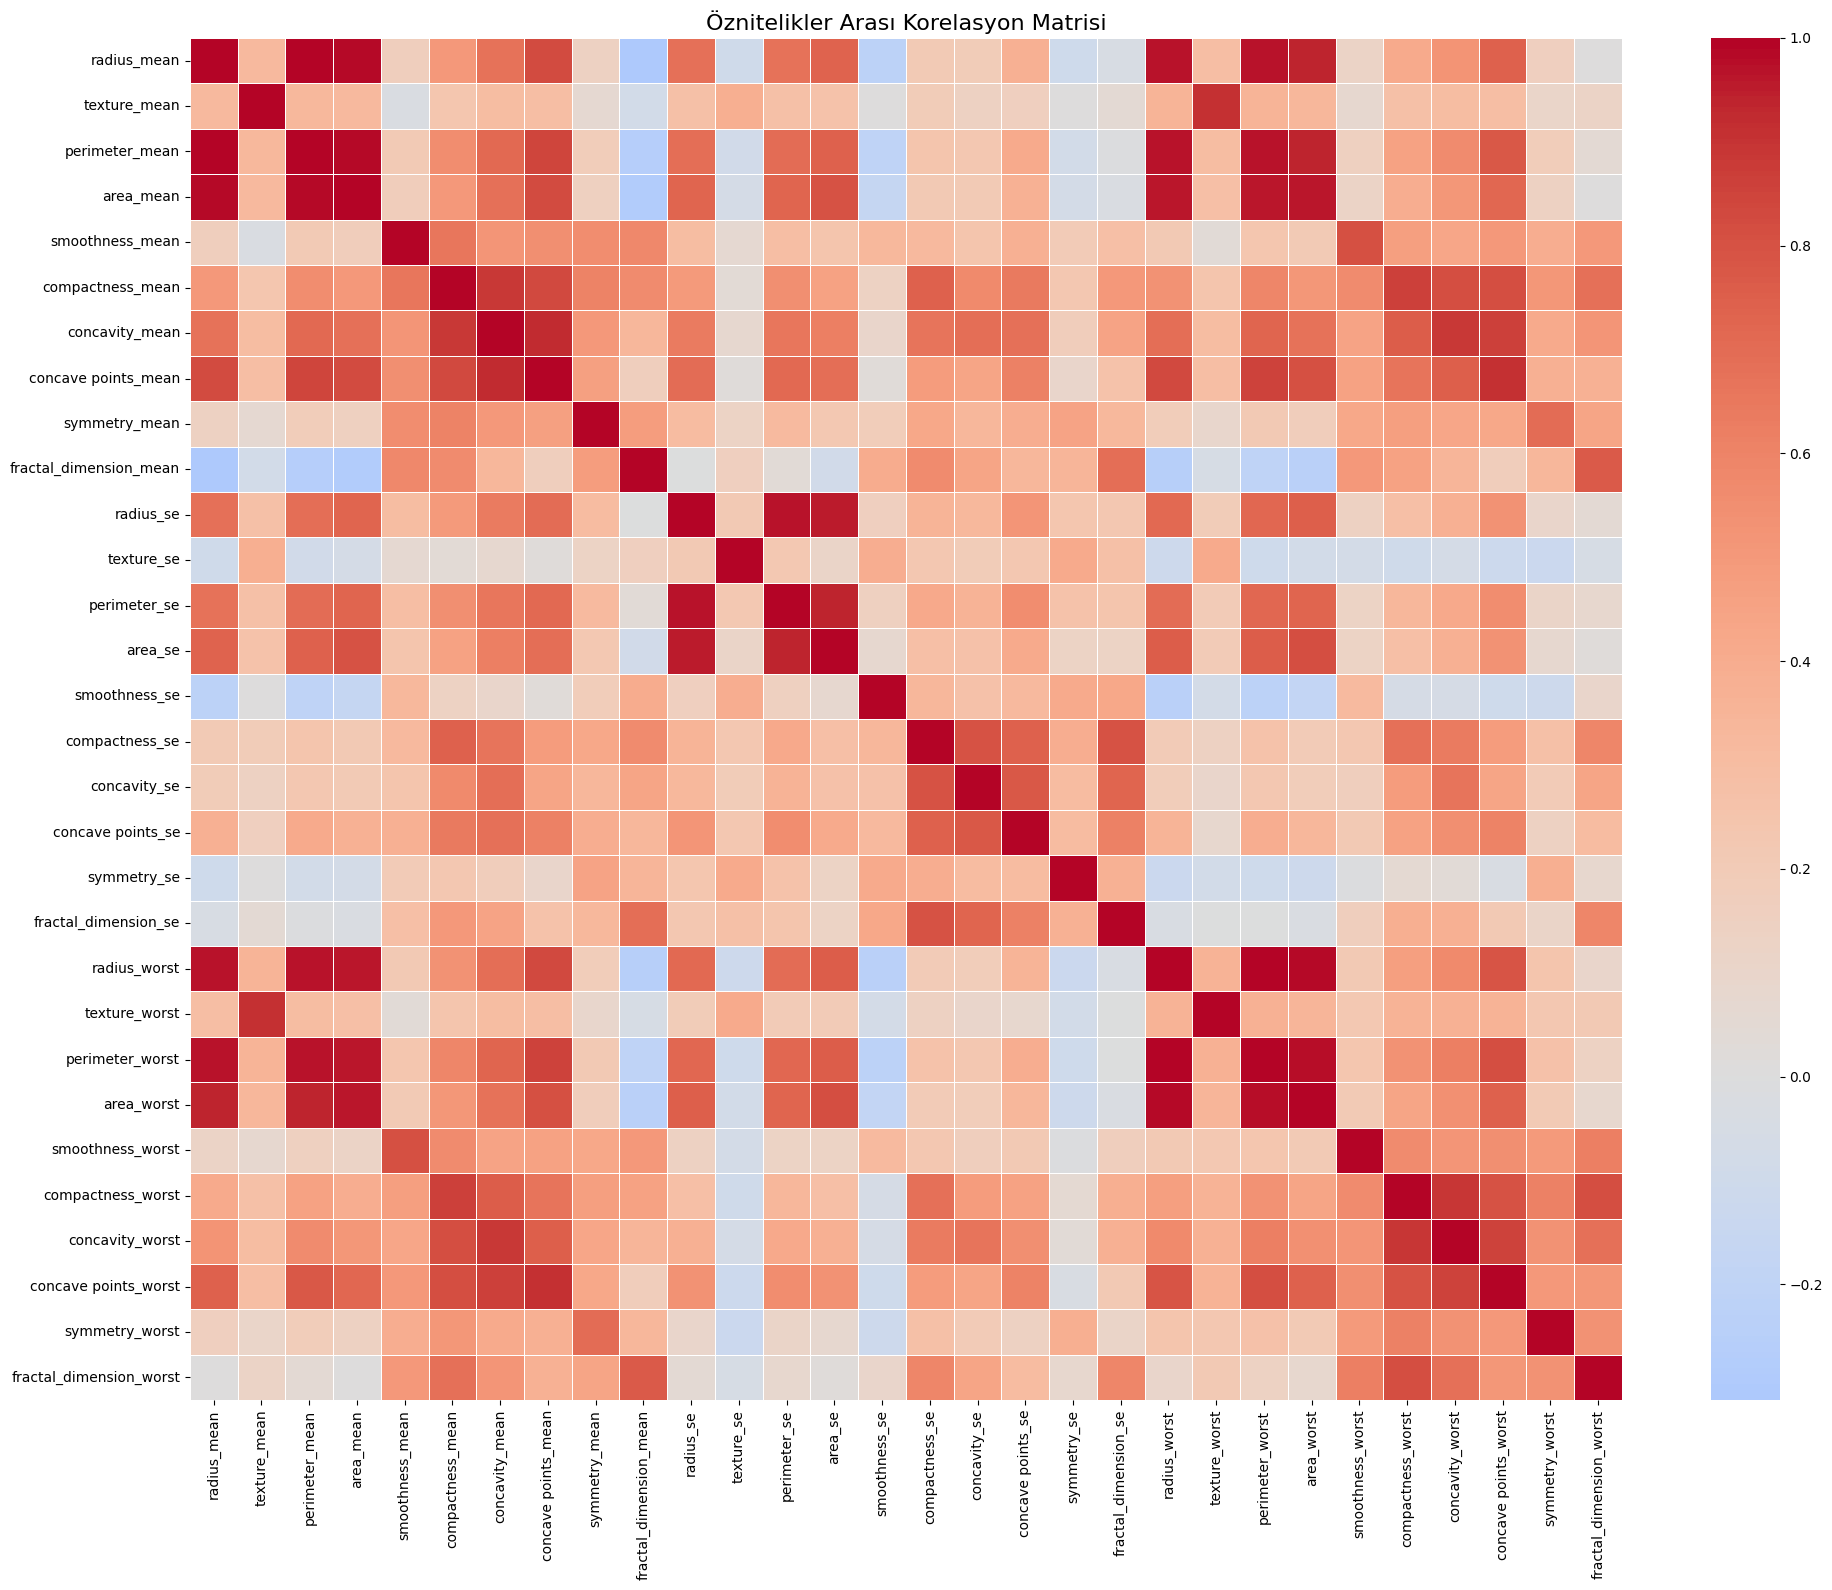


Silinen öznitelik sayısı: 10
Silinen öznitelikler: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']
Kalan öznitelik sayısı: 20

Eğitim seti: 455 örnek
Test seti  : 114 örnek


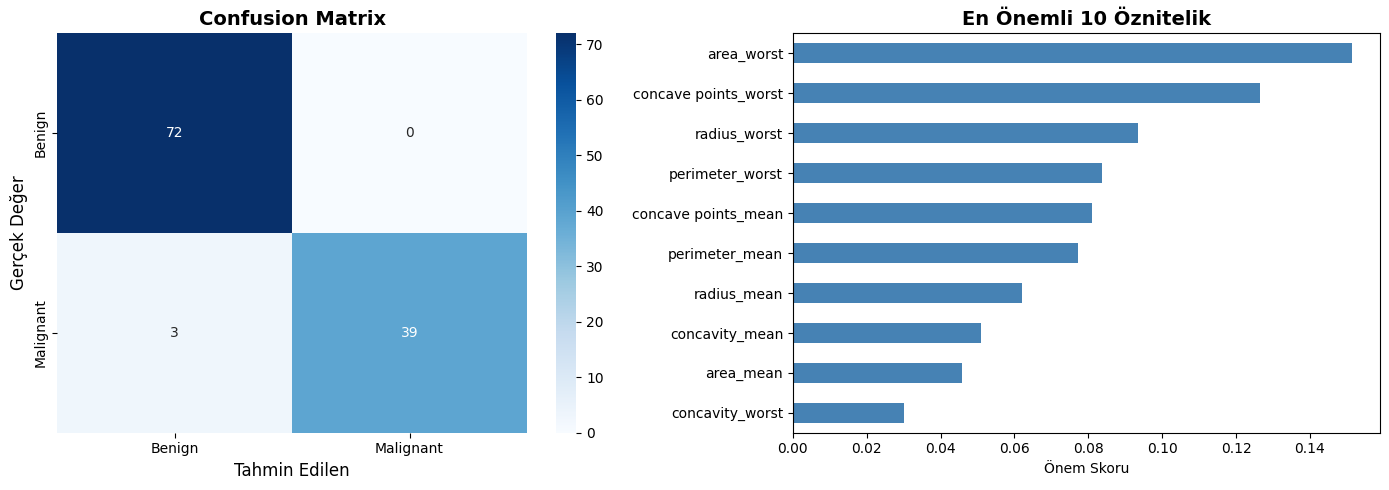


         KORELASYON ANALİZİ KARŞILAŞTIRMASI
                            Orijinal Filtrelenmiş
Öznitelik Sayısı                  30           20
Accuracy                      0.9737       0.9386
Precision                     1.0000       0.9487
Recall                        0.9286       0.8810
F1-Score                      0.9630       0.9136


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

df = pd.read_csv("sample_data/data.csv")

df.drop(columns=["id"], inplace=True, errors="ignore")
df.dropna(axis=1, how="all", inplace=True)

print("Veri Seti Boyutu:", df.shape)
print("Sınıf Dağılımı:\n", df["diagnosis"].value_counts())

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# KORELASYON ANALİZİ

# Korelasyon Heatmap
plt.figure(figsize=(20, 16))
corr_matrix = X.corr()
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            annot=False,
            linewidths=0.5)
plt.title("Öznitelikler Arası Korelasyon Matrisi", fontsize=16)
plt.tight_layout()
plt.show()

# Yüksek Korelasyonlu Öznitelikleri Sil
esik = 0.90
ust_ucgen = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
silinecekler = [sutun for sutun in ust_ucgen.columns
                if any(ust_ucgen[sutun] > esik)]

print(f"\nSilinen öznitelik sayısı: {len(silinecekler)}")
print(f"Silinen öznitelikler: {silinecekler}")

X_filtered = X.drop(columns=silinecekler)
print(f"Kalan öznitelik sayısı: {X_filtered.shape[1]}")

# Model eğitimi için veri satini bölme
# Orijinal X ile
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Filtrelenmiş X ile
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nEğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti  : {X_test.shape[0]} örnek")

# Model eğitimi
# Orijinal X ile model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Filtrelenmiş X ile model
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
axes[0].set_xlabel("Tahmin Edilen", fontsize=12)
axes[0].set_ylabel("Gerçek Değer", fontsize=12)
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")

# Öznitelik Önem Sıralaması (Top 10)
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()
top10.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("En Önemli 10 Öznitelik", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Önem Skoru")

plt.tight_layout()
plt.show()

# Filtrelenmiş ve orjinal performans kriterlerinin karşılaştırılması
print("\n" + "="*50)
print("         KORELASYON ANALİZİ KARŞILAŞTIRMASI")
print("="*50)
print(f"{'':25} {'Orijinal':>10} {'Filtrelenmiş':>12}")
print(f"{'Öznitelik Sayısı':25} {X.shape[1]:>10} {X_filtered.shape[1]:>12}")
print(f"{'Accuracy':25} {accuracy_score(y_test, y_pred):>10.4f} {accuracy_score(y_test2, y_pred2):>12.4f}")
print(f"{'Precision':25} {precision_score(y_test, y_pred):>10.4f} {precision_score(y_test2, y_pred2):>12.4f}")
print(f"{'Recall':25} {recall_score(y_test, y_pred):>10.4f} {recall_score(y_test2, y_pred2):>12.4f}")
print(f"{'F1-Score':25} {f1_score(y_test, y_pred):>10.4f} {f1_score(y_test2, y_pred2):>12.4f}")
print("="*50)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

# Verileri içinde bulunduran tablomu çektim
df = pd.read_csv("sample_data/data.csv")

df.drop(columns=["id"], inplace=True, errors="ignore")# Tablo üzerinde id sütununu sildim gereksiz bir sütün olduğu için
df.dropna(axis=1, how="all", inplace=True)# içerisinde eksik veri bulunan sütunları sildik burda

print("Veri Seti Boyutu:", df.shape)
print("Sınıf Dağılımı:\n", df["diagnosis"].value_counts())

le = LabelEncoder() # LabelEncoder nesnesi oluşturdum , labelEncoder nesnesi kategorik sütünlları sayısal veriye dönüştürür
#Burada hedef sütun olan diagnosis (tanı) sütunudur bu sütun içerisinde M (Malignant-Kötü huylu tümör) ve B (Benign-iyi huylu tümör) bulunur.
#Ve bulunan B ve M için alfabetik sırada sayısal atama yapılır B - 0 M - 1 olur ve sütun değiştirilir
df["diagnosis"] = le.fit_transform(df["diagnosis"])

#Burada girdi değişkenleri içe çıktı değişkenini ayırıyorum
X = df.drop(columns=["diagnosis"])#diagnosis yani tanı harici tüm tabloyu aldık burası girdi katmanı için kullanılanak özellikler kısmını belirtir
y = df["diagnosis"] # sadece diagnosis sütununu atarız burası da çıktı sonuç katmanını beltirtir.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Model seçimi ve inject edilmesi , burada random forest modelini seçtim. Farklı sayıda karar ağacından oluşan bu yapıda farklı farklı tahmiinlerde bulunur karar ağacları
#bu tahminlerin hangisi daha çok oy alırsa sonuç o olur, Burada n_estimators karar ağac sayısıdır burada genelde karar ağacı artarsa sonuçta iyileşme oluyormuş
#bende o yüzden 100-1000-10000 olacak şekilde 3 defa denedim ancak sonuçta bir iyileşme görmedim.
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
#modelin eğitilmesi
model.fit(X_train, y_train)

#Modelin tahminde bulunması burada X_test verisi üzerinden tahminde bulunucak hasta mı değil mi diye
y_pred = model.predict(X_test)

#test verisinin gerçek sonucu olan y_pred ile y_test verilerinin karşılaştırılması ile bulunan accuracy_score,precision_score,recall_score ve f1_score bulunması
print("\n========= METRİKLER =========")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")# burada Accuracy gerçek değerler ile tahmmin değerlerini karşılaştırır. Toplam tahminlerimizin % kaçı doğru buluruz
print(f"Precision : {precision_score(y_test, y_pred):.4f}") #Precision  modelin hasta (M-1 çünkü) dediklerinin % kaçı gerçekten hasta
print(f"Recall    : {recall_score(y_test, y_pred):.4f}") #Recall modelin hasta olanların % kaçına hasta dediğimizi buluruz
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}") # f1 skoru precision ve recall’ın harmonik ortalamasıdır
print("\n", classification_report(y_test, y_pred,
      target_names=["Benign", "Malignant"]))


Veri Seti Boyutu: (569, 31)
Sınıf Dağılımı:
 diagnosis
B    357
M    212
Name: count, dtype: int64

========= METRİKLER =========
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1-Score  : 0.9630

               precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

